Data Preprocessing:
Data preprocessing is the process of cleaning and organizing raw data to make it ready for a machine learning model. It fixes problems like missing information, wrong formats, and wild numbers so the computer can learn from the data accurately.

In [37]:
#Import required libraries and load the dataset
# Basic data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing tools from scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Make plots look clean
sns.set_style("whitegrid")

#Load Datasets
df = pd.read_csv("../data/hotel_bookings.csv")

print("Shape:", df.shape)
df.head()
df.info()


Shape: (119390, 32)
<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal   

In [38]:
#Basic Data Audit
print("Rows, Columns:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum()[df.isnull().sum() > 0])
print("\nDuplicate rows:", df.duplicated().sum())
print("\nADR (target) statistics:\n", df["adr"].describe())

Rows, Columns: (119390, 32)

Data types:
 hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
assigned_room_type                    str
booking_changes                     int64
deposit_type                      

C:\Users\manin\AppData\Local\Temp\ipykernel_23292\540990277.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing.values, y=missing.index, palette="tab10")


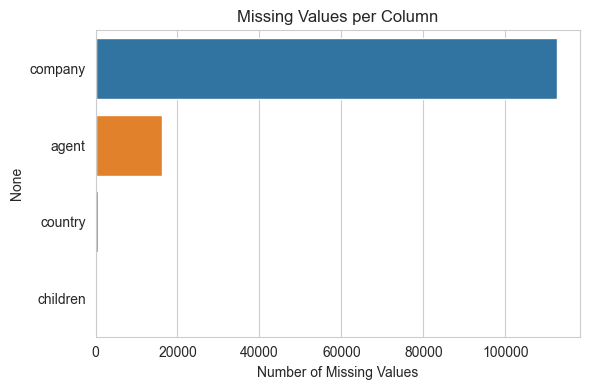

company     112593
agent        16340
country        488
children         4
dtype: int64


In [39]:
#Missing values analysis (visual)
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(6,4))
sns.barplot(x=missing.values, y=missing.index, palette="tab10")
plt.title("Missing Values per Column")
plt.xlabel("Number of Missing Values")
plt.tight_layout()
plt.show()

print(missing)

In [40]:
#Missing Value table
missing_table = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": df.isnull().mean() * 100
})

missing_table = missing_table[
    missing_table["Missing Count"] > 0
].sort_values("Missing Count", ascending=False)

missing_table

,Missing Count,Missing Percentage
company,112593,94.306893
agent,16340,13.686238
country,488,0.408744
children,4,0.003350


In [41]:
#Duplicate Analysis
duplicate_count = df.duplicated().sum()
print("Number of exact duplicate rows:", duplicate_count)

# Show a few duplicate rows as evidence
df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(6)

Number of exact duplicate rows: 31994


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
40772,City Hotel,0,0,2015,August,32,7,0,2,2,...,No Deposit,14.0,NaN,0,Transient,75.0,0,1,Check-Out,2015-08-09
40802,City Hotel,0,0,2015,August,32,7,0,2,2,...,No Deposit,14.0,NaN,0,Transient,75.0,0,1,Check-Out,2015-08-09
40821,City Hotel,0,0,2015,August,32,8,0,1,2,...,No Deposit,9.0,NaN,0,Transient,89.0,0,1,Check-Out,2015-08-09
40838,City Hotel,0,0,2015,August,32,8,0,1,2,...,No Deposit,9.0,NaN,0,Transient,89.0,0,1,Check-Out,2015-08-09
76792,City Hotel,0,0,2015,August,33,10,1,0,2,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-08-11
76793,City Hotel,0,0,2015,August,33,10,1,0,2,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-08-11


In [42]:
#Remove Duplicate Record
print("Shape before removing duplicates:", df.shape)

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape before removing duplicates: (119390, 32)
Shape after removing duplicates: (87396, 32)


In [43]:
#Handle Missing values
print("Missing values before handling:\n", df.isnull().sum()[df.isnull().sum() > 0])

# children: only 4 missing → assume no children were recorded for these bookings
df["children"] = df["children"].fillna(0)

# country: only 488 missing (small %) → fill with the most frequent country
most_common_country = df["country"].mode()[0]
df["country"] = df["country"].fillna(most_common_country)

# agent: missing means no agent was involved in this booking → use 0 as a valid "no agent" code
df["agent"] = df["agent"].fillna(0)

# company: missing means no company was involved in this booking → use 0 as a valid "no company" code
df["company"] = df["company"].fillna(0)

print("\nMissing values after handling:\n", df.isnull().sum().sum(), "missing values remain")

Missing values before handling:
 children        4
country       452
agent       12193
company     82137
dtype: int64

Missing values after handling:
 0 missing values remain


In [44]:
#Check Invalid / Suspicious Values
# --- ADR checks (target variable) ---
print("adr < 0:", (df["adr"] < 0).sum())
print("adr == 0:", (df["adr"] == 0).sum())
print("adr > 1000:", (df["adr"] > 1000).sum())
print(df[df["adr"] > 1000][["hotel","adr","adults","children"]])
print(df[df["adr"] < 0][["hotel","adr"]])

# --- Guest count checks ---
print("\nadults == 0:", (df["adults"] == 0).sum())
zero_guests = (df["adults"] == 0) & (df["children"] == 0) & (df["babies"] == 0)
print("adults==0 AND children==0 AND babies==0 (no guests at all):", zero_guests.sum())

# --- Stay length checks ---
total_nights_check = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]
print("\nBookings with total_nights == 0:", (total_nights_check == 0).sum())

adr < 0: 1
adr == 0: 1778
adr > 1000: 1
            hotel     adr  adults  children
48515  City Hotel  5400.0       2       0.0
              hotel   adr
14969  Resort Hotel -6.38

adults == 0: 385
adults==0 AND children==0 AND babies==0 (no guests at all): 166

Bookings with total_nights == 0: 651


In [45]:
# Apply only the two clearly justified removals: negative adr and the extreme outlier
before = df.shape[0]
df = df[df["adr"] >= 0]              # remove the impossible negative price
df = df[df["adr"] < 5000]            # remove the extreme outlier (single row at 5400)
after = df.shape[0]

print(f"Rows removed: {before - after}")
print("Shape after removing invalid adr rows:", df.shape)

Rows removed: 2
Shape after removing invalid adr rows: (87394, 32)


In [46]:
#Feature Engineering
# Total nights stayed (weekend + weekday nights combined)
df["total_nights"] = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]

# Total number of guests in the booking
df["total_guests"] = df["adults"] + df["children"] + df["babies"]

# Total previous bookings (cancelled + not cancelled) — shows guest history
df["total_previous_bookings"] = df["previous_cancellations"] + df["previous_bookings_not_canceled"]

# Extra feature 1: is this a family booking? (has at least one child or baby)
df["is_family"] = ((df["children"] > 0) | (df["babies"] > 0)).astype(int)

# Extra feature 2: average price per guest info isn't safe (would leak adr), 
# so instead: total special requests + car parking as a simple "customer engagement" score
df["engagement_score"] = df["total_of_special_requests"] + df["required_car_parking_spaces"]

df[["total_nights","total_guests","total_previous_bookings","is_family","engagement_score"]].head()

,total_nights,total_guests,total_previous_bookings,is_family,engagement_score
0,0,2.0,0,0,0
1,0,2.0,0,0,0
2,1,1.0,0,0,0
3,1,1.0,0,0,0
4,2,2.0,0,0,1


In [47]:
#Prepare X and y
y = df["adr"]
X = df.drop(columns=["adr"])

print("y shape:", y.shape)
print("X shape:", X.shape)
print("Is 'adr' still in X?", "adr" in X.columns)

y shape: (87394,)
X shape: (87394, 36)
Is 'adr' still in X? False


In [48]:
#Remove Leakage Columns
leakage_cols = ["reservation_status", "reservation_status_date"]

print("Columns before removing leakage:", X.shape[1])
X = X.drop(columns=leakage_cols)
print("Columns after removing leakage:", X.shape[1])

Columns before removing leakage: 36
Columns after removing leakage: 34


In [49]:
#Identify Numerical and Categorical Columns
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical features:", len(numeric_cols))
print(numeric_cols)

print("\nCategorical features:", len(categorical_cols))
print(categorical_cols)

Numerical features: 24
['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'required_car_parking_spaces', 'total_of_special_requests', 'total_nights', 'total_guests', 'total_previous_bookings', 'is_family', 'engagement_score']

Categorical features: 10
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']


C:\Users\manin\AppData\Local\Temp\ipykernel_23292\427770555.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()


In [50]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (69915, 34)
X_test: (17479, 34)
y_train: (69915,)
y_test: (17479,)


In [51]:
#Build the ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)
preprocessor


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [52]:
#Fit on Train, Transform Train and Test (No Leakage)
# Fit ONLY on training data — this is the key rule to avoid data leakage
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data using the SAME already-fitted preprocessor (do not re-fit!)
X_test_processed = preprocessor.transform(X_test)

print("X_train_processed shape:", X_train_processed.shape)
print("X_test_processed shape:", X_test_processed.shape)

X_train_processed shape: (69915, 253)
X_test_processed shape: (17479, 253)


In [53]:
print("=== FINAL PREPROCESSED DATA SUMMARY ===")
print("X_train shape:", X_train_processed.shape)
print("X_test shape:", X_test_processed.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nNumber of numeric features (before encoding):", len(numeric_cols))
print("Number of categorical features (before encoding):", len(categorical_cols))
print("Total features after encoding:", X_train_processed.shape[1])

print("\nAny missing values left in X_train?", pd.isnull(X_train).sum().sum())
print("Any missing values left in y_train?", y_train.isnull().sum())

print("\nPreprocessing complete. Ready for regression.ipynb")

=== FINAL PREPROCESSED DATA SUMMARY ===
X_train shape: (69915, 253)
X_test shape: (17479, 253)
y_train shape: (69915,)
y_test shape: (17479,)

Number of numeric features (before encoding): 24
Number of categorical features (before encoding): 10
Total features after encoding: 253

Any missing values left in X_train? 0
Any missing values left in y_train? 0

Preprocessing complete. Ready for regression.ipynb


In [54]:
print("=== CLEANED DATASET ===")
print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicates:", df.duplicated().sum())

df.head(10)

=== CLEANED DATASET ===
Shape: (87394, 37)
Missing values: 0
Duplicates: 19


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_nights,total_guests,total_previous_bookings,is_family,engagement_score
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,0.0,0,0,Check-Out,2015-07-01,0,2.0,0,0,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,0.0,0,0,Check-Out,2015-07-01,0,2.0,0,0,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,75.0,0,0,Check-Out,2015-07-02,1,1.0,0,0,0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,75.0,0,0,Check-Out,2015-07-02,1,1.0,0,0,0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,98.0,0,1,Check-Out,2015-07-03,2,2.0,0,0,1
6,Resort Hotel,0,0,2015,July,27,1,0,2,2,...,107.0,0,0,Check-Out,2015-07-03,2,2.0,0,0,0
7,Resort Hotel,0,9,2015,July,27,1,0,2,2,...,103.0,0,1,Check-Out,2015-07-03,2,2.0,0,0,1
8,Resort Hotel,1,85,2015,July,27,1,0,3,2,...,82.0,0,1,Canceled,2015-05-06,3,2.0,0,0,1
9,Resort Hotel,1,75,2015,July,27,1,0,3,2,...,105.5,0,0,Canceled,2015-04-22,3,2.0,0,0,0
10,Resort Hotel,1,23,2015,July,27,1,0,4,2,...,123.0,0,0,Canceled,2015-06-23,4,2.0,0,0,0


In [55]:
#Before vs After Comparison Table
# Reload the original file just to compare (does not overwrite your cleaned df)
df_original = pd.read_csv("../data/hotel_bookings.csv")

comparison = pd.DataFrame({
    "Stage": ["Original", "Cleaned"],
    "Rows": [df_original.shape[0], df.shape[0]],
    "Columns": [df_original.shape[1], df.shape[1]],
    "Missing Values": [df_original.isnull().sum().sum(), df.isnull().sum().sum()],
    "Duplicate Rows": [df_original.duplicated().sum(), df.duplicated().sum()]
})

comparison

,Stage,Rows,Columns,Missing Values,Duplicate Rows
0,Original,119390,32,129425,31994
1,Cleaned,87394,37,0,19


In [56]:
#Show the Encoded/Scaled Data (after ColumnTransformer)
# Get the feature names created by the ColumnTransformer
feature_names = preprocessor.get_feature_names_out()

# The output is a SPARSE matrix, so convert to a dense array first
X_train_df = pd.DataFrame(
    X_train_processed.toarray(),
    columns=feature_names
)

print("Encoded training data shape:", X_train_df.shape)
X_train_df.head()

Encoded training data shape: (69915, 253)


,num__is_canceled,num__lead_time,num__arrival_date_year,num__arrival_date_week_number,num__arrival_date_day_of_month,num__stays_in_weekend_nights,num__stays_in_week_nights,num__adults,num__children,num__babies,...,cat__assigned_room_type_I,cat__assigned_room_type_K,cat__assigned_room_type_P,cat__deposit_type_No Deposit,cat__deposit_type_Non Refund,cat__deposit_type_Refundable,cat__customer_type_Contract,cat__customer_type_Group,cat__customer_type_Transient,cat__customer_type_Transient-Party
0,-0.616266,-0.870061,-0.309344,-1.810180,-1.337327,-0.002800,0.186154,0.193028,-0.303773,-0.098133,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-0.616266,-0.800234,1.149135,-1.518196,-1.224144,0.971180,-1.285515,-1.366252,-0.303773,-0.098133,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,1.622677,1.306206,-0.309344,0.379696,-1.337327,-0.002800,0.186154,1.752309,-0.303773,-0.098133,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,-0.616266,-0.381274,-0.309344,0.890668,0.699962,-0.976780,0.186154,0.193028,-0.303773,-0.098133,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1.622677,2.469986,1.149135,-0.204270,-0.205500,6.815062,8.035054,-1.366252,-0.303773,-0.098133,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


In [57]:
# Save the cleaned dataset (readable, before encoding) for your report/GitHub
df.to_csv("../data/hotel_bookings_cleaned.csv", index=False)

print("Saved cleaned dataset to ../data/hotel_bookings_cleaned.csv")
print("Shape:", df.shape)

Saved cleaned dataset to ../data/hotel_bookings_cleaned.csv
Shape: (87394, 37)
